<a href="https://colab.research.google.com/github/arajesh3097/Data-Science-Project/blob/main/Winequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning-Based Classification of Wine Quality Tiers Based on Physicochemical Tests**

# **Part 1: Loading Dataset**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets (using ';' as the separator based on the file format)
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

# Add a 'type' column to distinguish between red and white wine
red_wine['type'] = 'red'
white_wine['type'] = 'white'

# Combine datasets for a comprehensive analysis
df_combined = pd.concat([red_wine, white_wine], ignore_index=True)

# Quick check of the shapes
print(f"Red Wine Rows: {red_wine.shape[0]}")
print(f"White Wine Rows: {white_wine.shape[0]}")
print(f"Combined Rows: {df_combined.shape[0]}")



Red Wine Rows: 1599
White Wine Rows: 4898
Combined Rows: 6497


# **Part 2: Exploratory Data Analysis**

## **Dataset Inspection**

In [4]:
red_wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [5]:
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


In [6]:
df_combined.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [7]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## **Descriptive Statistical Analysis**

In [8]:
df_combined.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## **Check for Missing Values**

Missing Values per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


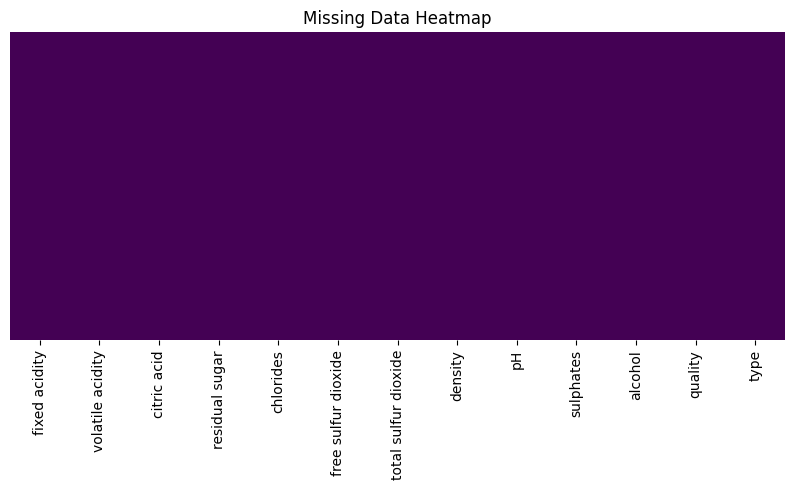

In [9]:
# Checking for missing values in each column
print("Missing Values per Column:")
print(df_combined.isnull().sum())

# Visualizing missing values using a heatmap (optional but helpful)
plt.figure(figsize=(10, 4))
sns.heatmap(df_combined.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

## **Target Variable (Quality) Distribution**

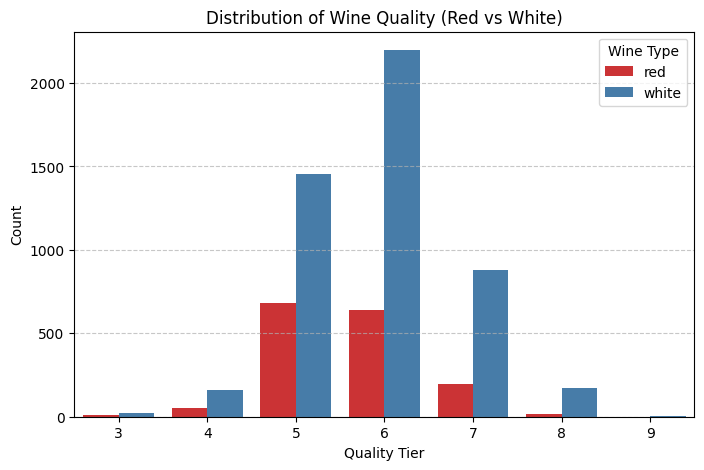

Quality Score Counts:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [10]:
# Visualize the distribution of the target variable 'quality'
plt.figure(figsize=(8, 5))
sns.countplot(data=df_combined, x='quality', hue='type', palette='Set1')
plt.title('Distribution of Wine Quality (Red vs White)')
plt.xlabel('Quality Tier')
plt.ylabel('Count')
plt.legend(title='Wine Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the numerical counts
print("Quality Score Counts:")
print(df_combined['quality'].value_counts().sort_index())

## **Box Plots (Outlier and Relationship Analysis)**

/tmp/ipykernel_916/545668135.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df_combined, palette='coolwarm')
/tmp/ipykernel_916/545668135.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df_combined, palette='coolwarm')
/tmp/ipykernel_916/545668135.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df_combined, palette='coolwarm')
/tmp/ipykernel_916/545668135.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

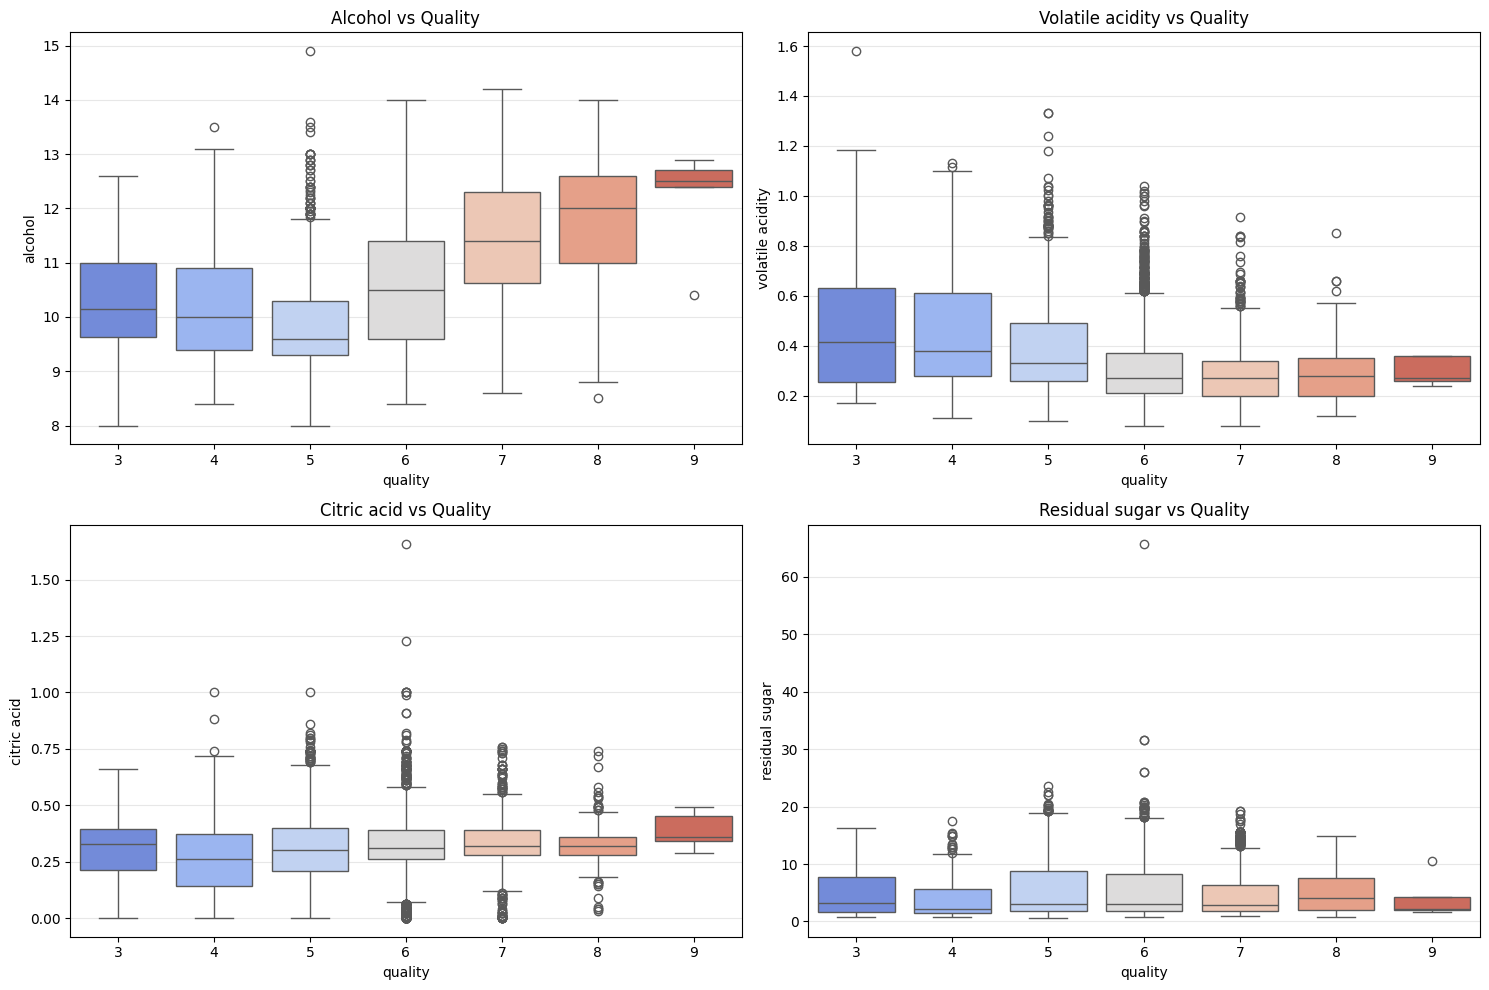

In [11]:
# List of features to plot against quality
features = ['alcohol', 'volatile acidity', 'citric acid', 'residual sugar']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='quality', y=feature, data=df_combined, palette='coolwarm')
    plt.title(f'{feature.capitalize()} vs Quality')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **Scatter Plots (Feature Correlation Analysis)**

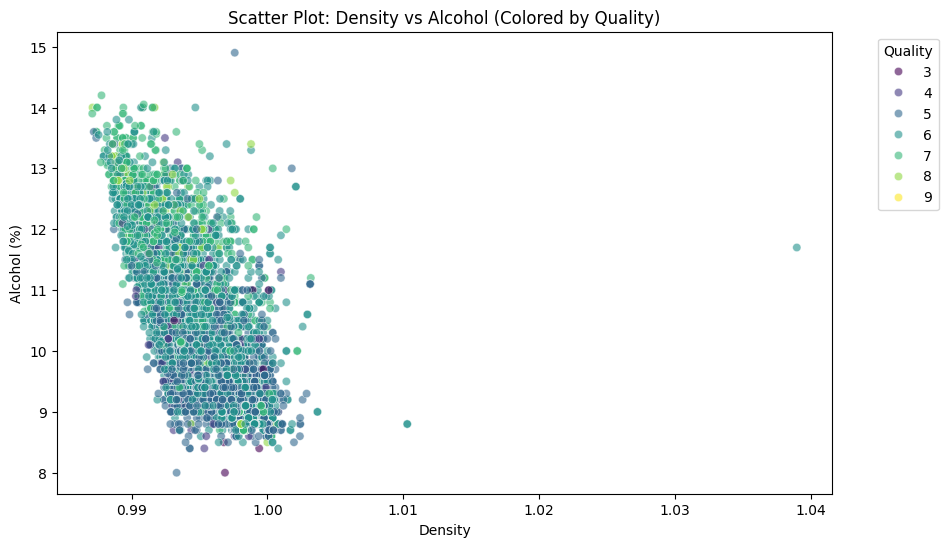

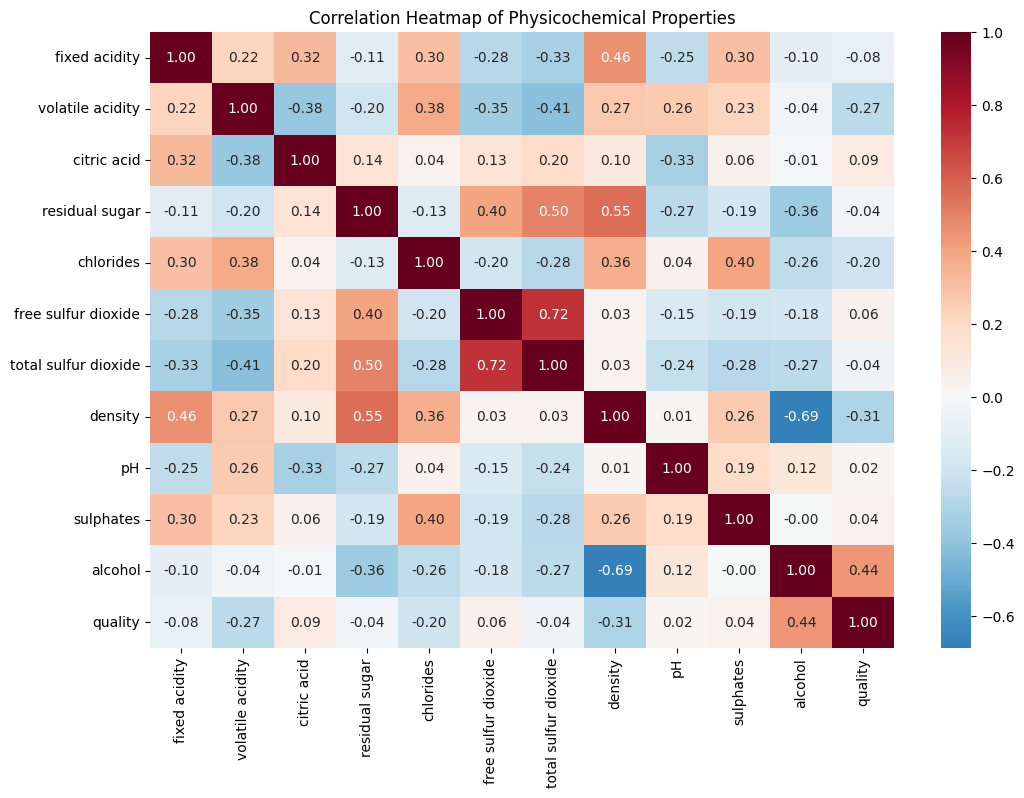

In [12]:
# Scatter plot between Alcohol and Density colored by Quality
plt.figure(figsize=(10, 6))
sns.scatterplot(x='density', y='alcohol', hue='quality', data=df_combined, palette='viridis', alpha=0.6)
plt.title('Scatter Plot: Density vs Alcohol (Colored by Quality)')
plt.xlabel('Density')
plt.ylabel('Alcohol (%)')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Correlation Heatmap to see overall feature interactions
plt.figure(figsize=(12, 8))
sns.heatmap(df_combined.drop('type', axis=1).corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Physicochemical Properties')
plt.show()

# **Data Preprocessing**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Basic Cleaning
# Removing duplicates to ensure the model doesn't overfit on repeated rows
df_ml = df_combined.drop_duplicates().copy()

# 2. Encoding the Target Variable ('type')
# This converts 'red' and 'white' into 0 and 1
le = LabelEncoder()
y = le.fit_transform(df_ml['type'])

# 3. Feature Selection
# 'type' is now the target (y), so we drop it from features (X)
# 'quality' remains in X as an input feature
X = df_ml.drop(columns=['type'])

# 4. Feature Scaling
# This is crucial for wine data because 'total sulfur dioxide' has
# much higher values than 'chlorides' or 'pH'.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-Test Split
# We use 'stratify=y' to ensure the ratio of red/white wine
# is the same in both training and testing sets.
X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocessing for 'type' classification complete.")
print(f"Features used: {list(X.columns)}")
print(f"Classes: {le.classes_} -> mapped to [0, 1]")

Preprocessing for 'type' classification complete.
Features used: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Classes: ['red' 'white'] -> mapped to [0, 1]


# **Model Training & Evaluations**


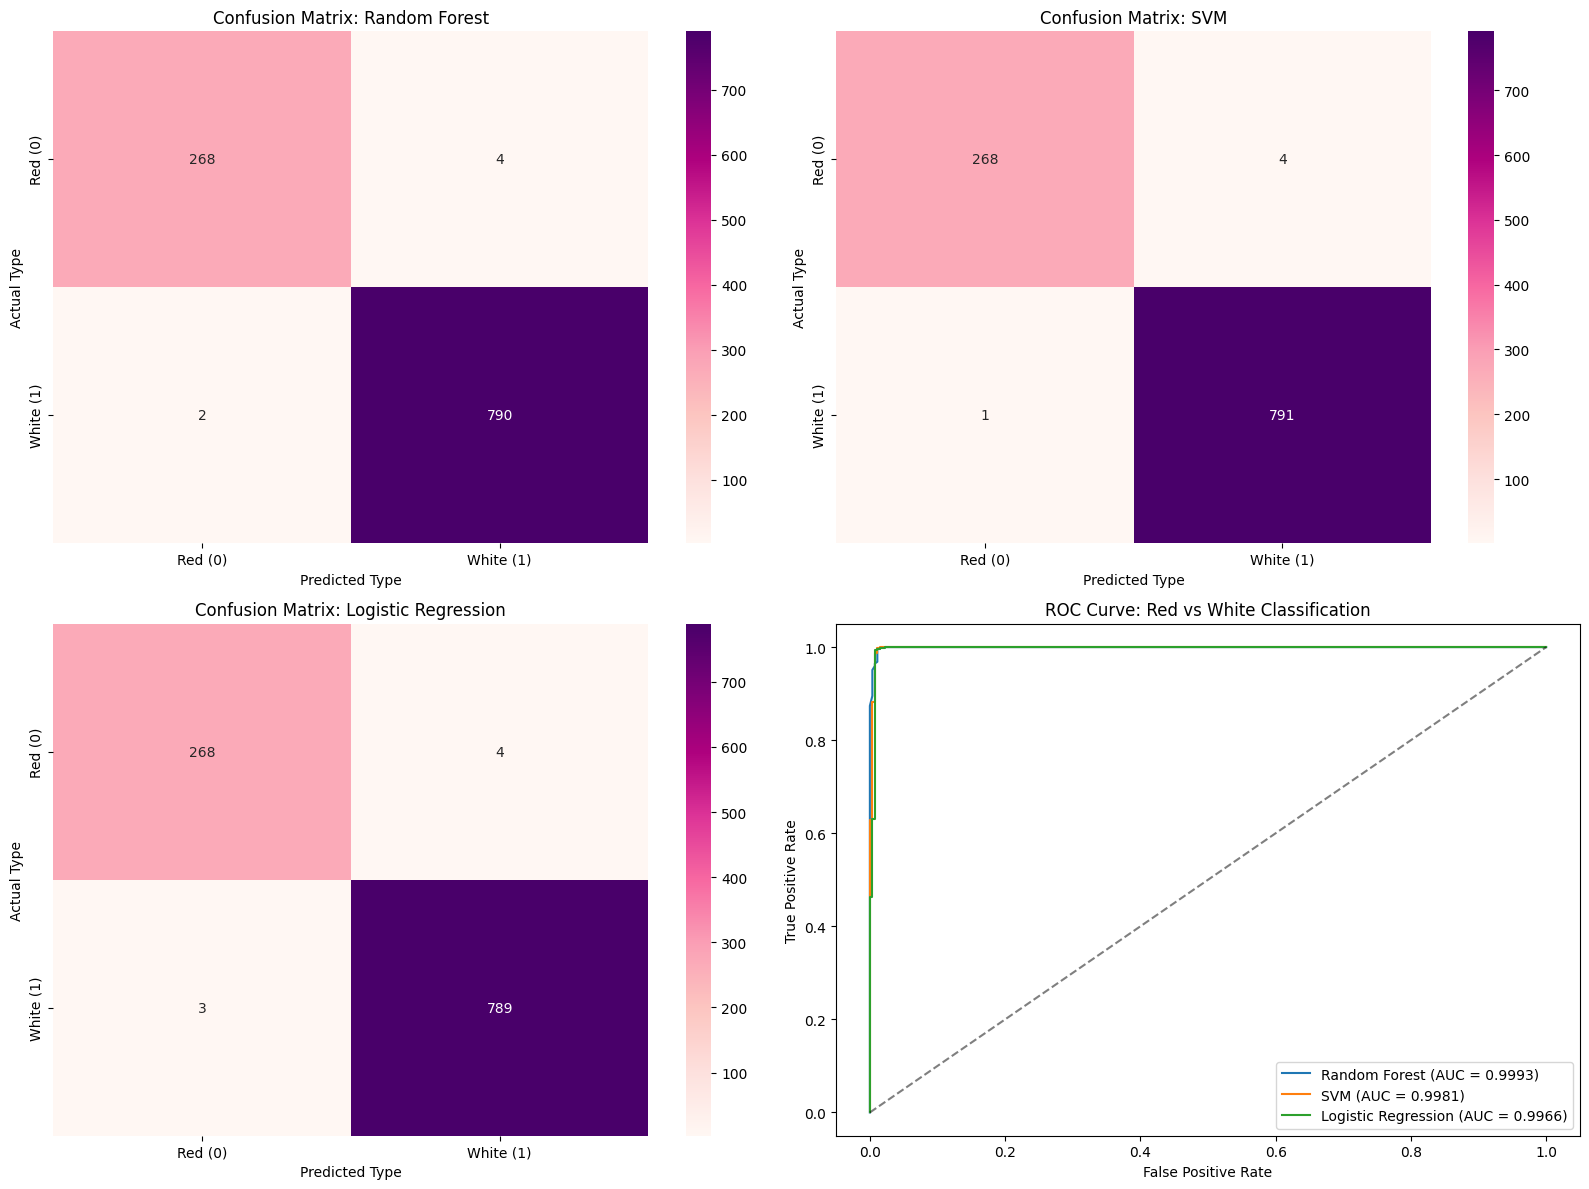


FINAL SUMMARIZED PERFORMANCE


,Accuracy,Precision,Recall,F1-Score,Train Time (s),Test Time (s)
Model,,,,,,
Random Forest,0.994361,0.994962,0.997475,0.996217,0.8338,0.0175
SVM,0.995301,0.994969,0.998737,0.996849,0.4812,0.0268
Logistic Regression,0.993421,0.994956,0.996212,0.995584,0.0607,0.0004


In [14]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# --- Configuration ---
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results_list = []
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# --- Execution ---
for i, (name, model) in enumerate(models.items()):
    # 1. Performance Timing
    start_train = time.time()
    model.fit(X_train_comb, y_train_comb)
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred = model.predict(X_test_comb)
    test_time = time.time() - start_test

    # 2. Metric Calculation
    acc = accuracy_score(y_test_comb, y_pred)
    prec = precision_score(y_test_comb, y_pred)
    rec = recall_score(y_test_comb, y_pred)
    f1 = f1_score(y_test_comb, y_pred)

    results_list.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1,
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

    # 3. Confusion Matrix Visualization
    cm = confusion_matrix(y_test_comb, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='RdPu',
                xticklabels=['Red (0)', 'White (1)'],
                yticklabels=['Red (0)', 'White (1)'])
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Type")
    axes[i].set_ylabel("Actual Type")

# --- 4. ROC Curve Comparison ---
for name, model in models.items():
    y_probs = model.predict_proba(X_test_comb)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_comb, y_probs)
    roc_auc = auc(fpr, tpr)
    axes[3].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

axes[3].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[3].set_title("ROC Curve: Red vs White Classification")
axes[3].set_xlabel("False Positive Rate")
axes[3].set_ylabel("True Positive Rate")
axes[3].legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- 5. Summarized Matrix ---
df_performance = pd.DataFrame(results_list).set_index("Model")
print("\n" + "="*30)
print("FINAL SUMMARIZED PERFORMANCE")
print("="*30)
display(df_performance)

# **Hyperparameter Optimization with Grid Search**

Tuning Random Forest...
Tuning SVM...
Tuning Logistic Regression...


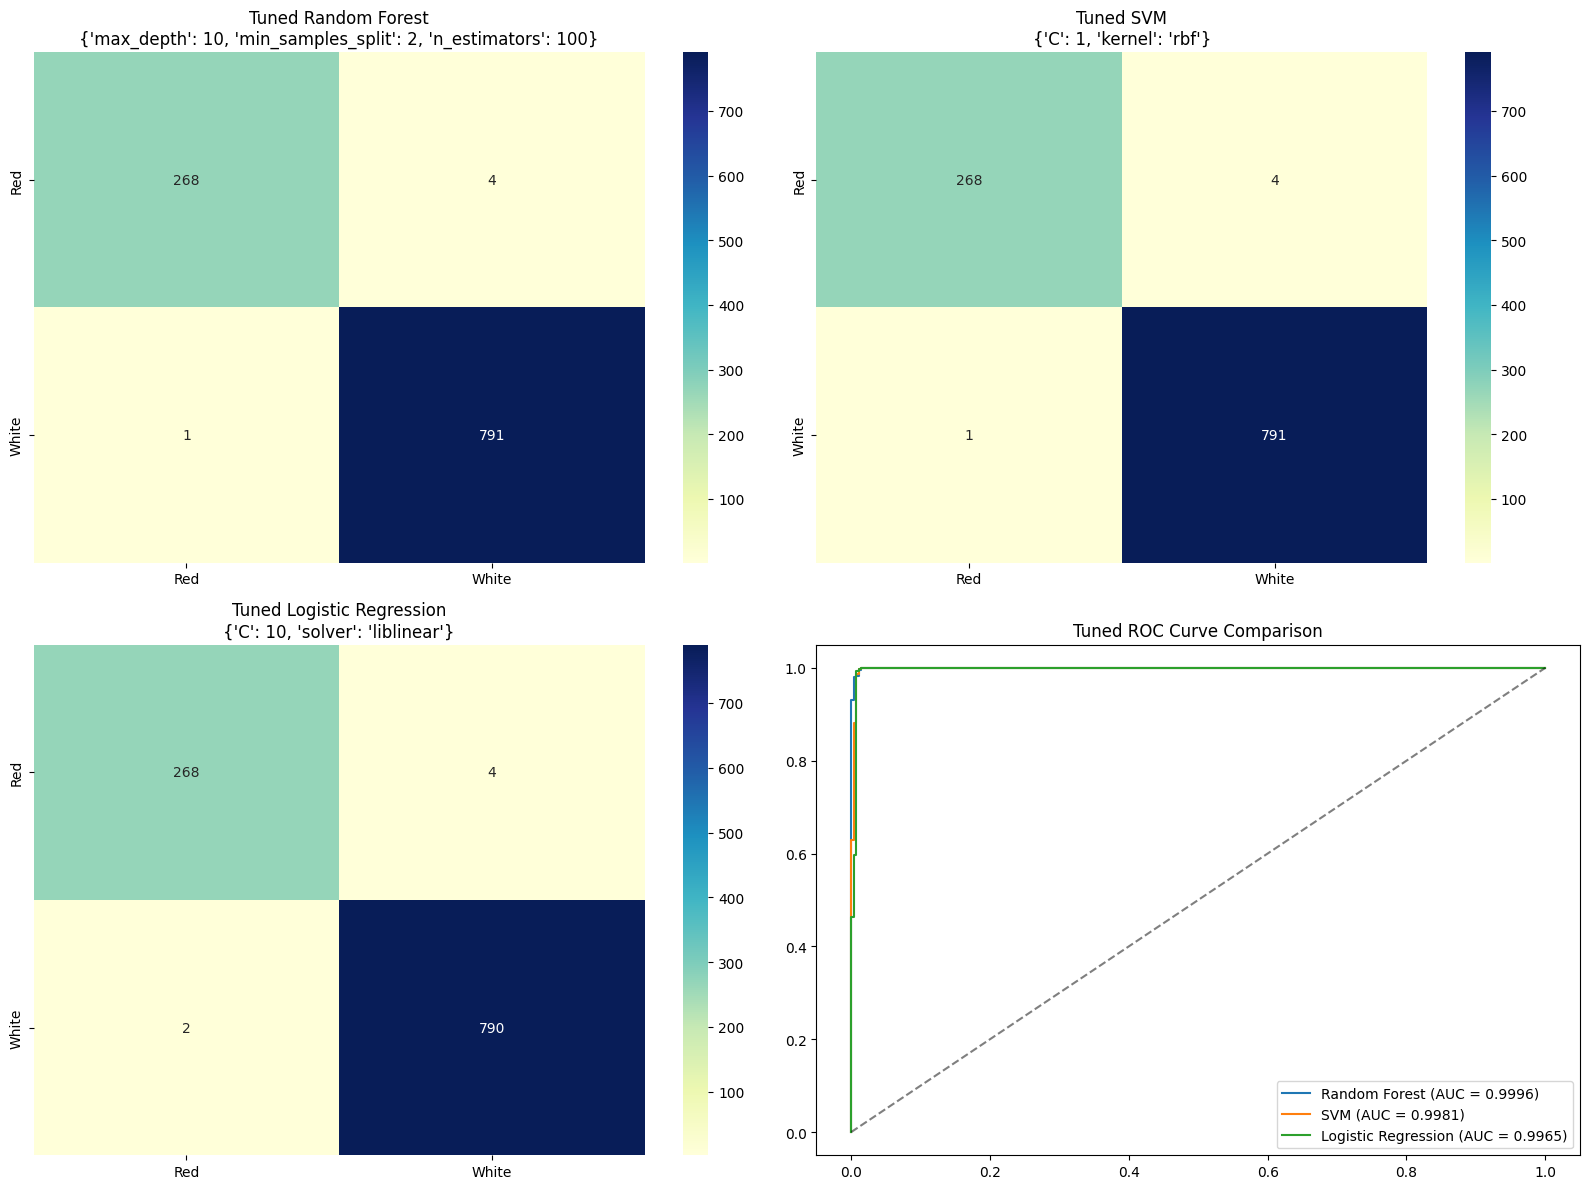


--- HYPERPARAMETER TUNED RESULTS ---


,Best Params,Accuracy,Precision,Recall,F1-Score,Train Time (s),Test Time (s)
Model,,,,,,,
Random Forest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.995301,0.994969,0.998737,0.996849,27.1205,0.0118
SVM,"{'C': 1, 'kernel': 'rbf'}",0.995301,0.994969,0.998737,0.996849,6.9767,0.0135
Logistic Regression,"{'C': 10, 'solver': 'liblinear'}",0.994361,0.994962,0.997475,0.996217,0.3541,0.0003


In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define Parameter Grids for each model
param_grids = {
    "Random Forest": {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    }
}

best_models = {}
tuned_results = []

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# 2. Run GridSearch and Evaluate
for i, (name, model) in enumerate(models.items()):
    print(f"Tuning {name}...")

    # Initialize GridSearch
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)

    start_train = time.time()
    grid_search.fit(X_train_comb, y_train_comb)
    train_time = time.time() - start_train

    # Get the best estimator
    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    # Testing
    start_test = time.time()
    y_pred = best_model.predict(X_test_comb)
    test_time = time.time() - start_test

    # Metrics
    acc = accuracy_score(y_test_comb, y_pred)
    prec = precision_score(y_test_comb, y_pred)
    rec = recall_score(y_test_comb, y_pred)
    f1 = f1_score(y_test_comb, y_pred)

    tuned_results.append({
        "Model": name, "Best Params": grid_search.best_params_,
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1,
        "Train Time (s)": round(train_time, 4), "Test Time (s)": round(test_time, 4)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test_comb, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='YlGnBu',
                xticklabels=['Red', 'White'], yticklabels=['Red', 'White'])
    axes[i].set_title(f"Tuned {name}\n{grid_search.best_params_}")

# 3. Tuned ROC Curve
for name, model in best_models.items():
    y_probs = model.predict_proba(X_test_comb)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_comb, y_probs)
    roc_auc = auc(fpr, tpr)
    axes[3].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

axes[3].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[3].set_title("Tuned ROC Curve Comparison")
axes[3].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 4. Summarized Matrix
df_tuned = pd.DataFrame(tuned_results).set_index("Model")
print("\n--- HYPERPARAMETER TUNED RESULTS ---")
display(df_tuned)